<a href="https://colab.research.google.com/github/raissaesteves/Fonte-de-Informa-o-e-Banco-de-Dados/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conheça o Colab

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

100%|██████████| 1.47k/1.47k [00:00<00:00, 914kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/raphaelmanayon/temperature-and-ice-cream-sales/versions/1


In [8]:
import pandas as pd
import os

# Assuming the CSV file is named 'Ice Cream Sales - temperatures.csv' inside the downloaded directory
csv_file_path = os.path.join(path, 'Ice Cream Sales - temperatures.csv')

df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head(10))

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
5,43,15.88
6,44,19.07
7,44,19.57
8,45,21.62
9,45,22.34


### Performing Linear Regression

First, I'll prepare the data by defining the independent variable (Temperature) and the dependent variable (Ice Cream Profits). Then, I'll split the data into training and testing sets to evaluate the model's performance on unseen data. Finally, I'll train a linear regression model.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define independent (X) and dependent (y) variables
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully.")
print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


Linear Regression Model Trained Successfully.
Coefficient (slope): 1.19
Intercept: -33.66


### Model Evaluation and Visualization

Now, let's evaluate the trained model using the test set and visualize the regression line against the actual data points.

In [24]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, color='blue', label='Actual Data')
plt.plot(X_test['Temperature'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Temperature vs. Ice Cream Profits (Linear Regression)')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.legend()
plt.grid(True)
plt.show()

Mean Squared Error (MSE): 5.29
R-squared (R2): 0.98


ValueError: Data must be 1-dimensional, got ndarray of shape (365, 1) instead

<Figure size 1000x600 with 0 Axes>

In [26]:
from sklearn.linear_model import LinearRegression

# Define the independent variable (X) and dependent variable (y)
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Create a linear regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Print the coefficient and intercept
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Equação: {model.coef_[0]:.2f}*x + {model.intercept_:.2f}")

Coefficient (Slope): 1.19
Intercept: -33.70
Equação: 1.19*x + -33.70


### Comparação Visual: Valores Reais vs. Valores Previstos

Agora, vamos visualizar a relação entre a temperatura e os lucros de sorvete, e como a linha de regressão se ajusta aos dados reais.

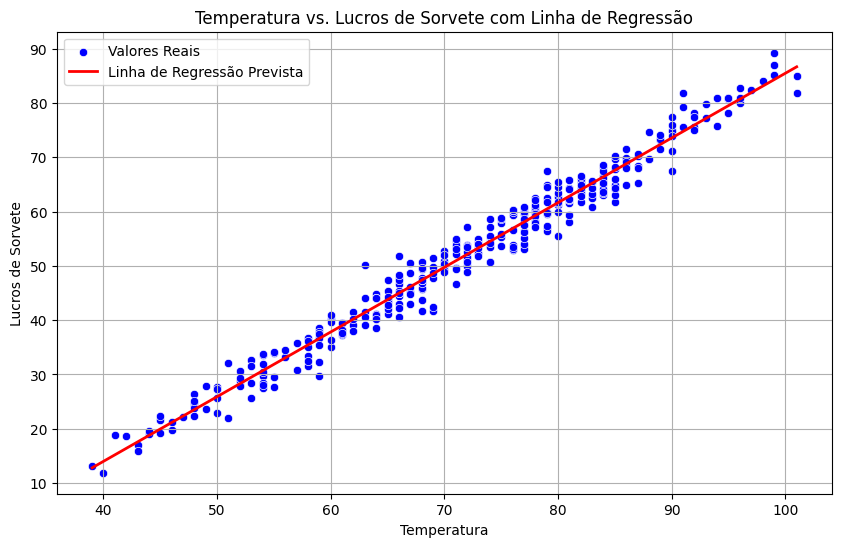

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the model on the entire dataset (X)
# X was defined earlier as df[['Temperature']]
y_full_pred = model.predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['Temperature'], y=y, color='blue', label='Valores Reais')
plt.plot(X['Temperature'], y_full_pred, color='red', linewidth=2, label='Linha de Regressão Prevista')
plt.title('Temperatura vs. Lucros de Sorvete com Linha de Regressão')
plt.xlabel('Temperatura')
plt.ylabel('Lucros de Sorvete')
plt.legend()
plt.grid(True)
plt.show()